In [2]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load clean data

df = pd.read_csv("clean_runs.csv")
df = df[df["status"] == "success"].copy()

df[["prompt_style", "input_tokens", "output_tokens", "latency_sec", "energy_joules"]].head()

,prompt_style,input_tokens,output_tokens,latency_sec,energy_joules
0,concise,29,128,147.746174,1288.388060
1,structured,35,128,105.815135,924.702571
2,verbose,28,128,116.037042,1022.581733
3,cot,31,128,110.868817,981.459992
4,concise,38,128,100.459757,883.836531


In [3]:
# Calculate Pearson Correlations between key runtime variables

corr_tokens_energy = df["output_tokens"].corr(df["energy_joules"])
corr_tokens_latency = df["output_tokens"].corr(df["latency_sec"])
corr_latency_energy = df["latency_sec"].corr(df["energy_joules"])

# Print correlational results for analysis

print("Output Tokens vs Energy:", round(corr_tokens_energy, 3))
print("Output Tokens vs Latency:", round(corr_tokens_latency, 3))
print("Latency vs Energy:", round(corr_latency_energy, 3))

Output Tokens vs Energy: 0.856
Output Tokens vs Latency: 0.874
Latency vs Energy: 0.999


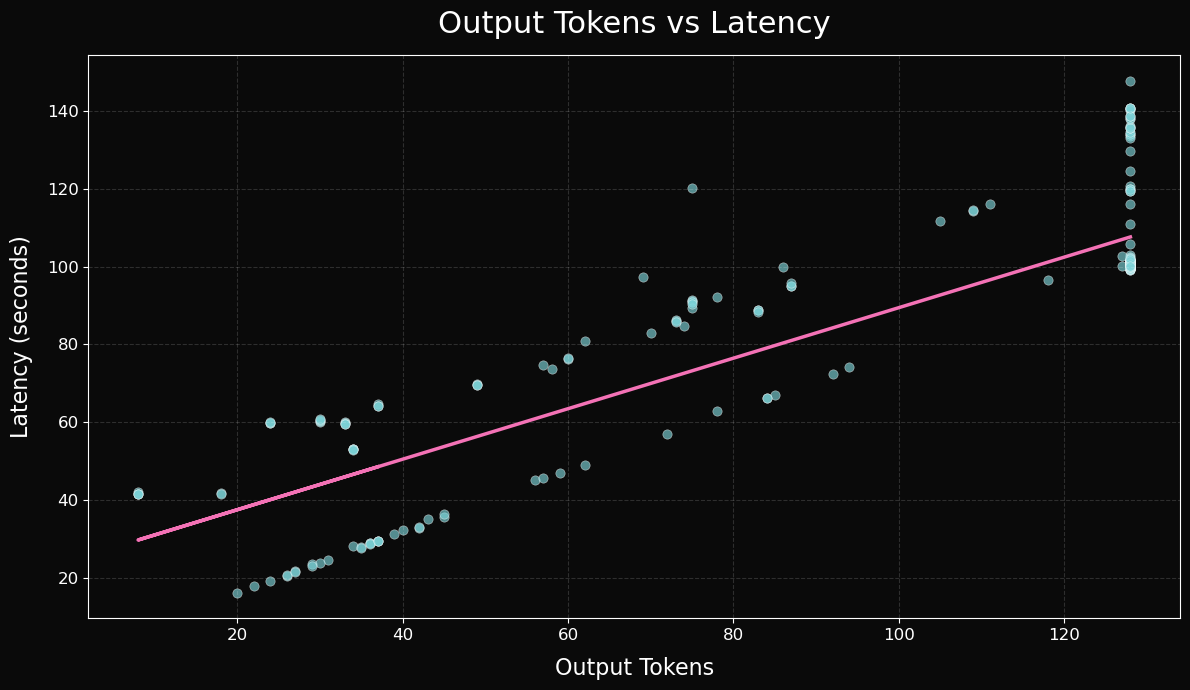

In [4]:
# Scatter plot between output tokens and latency

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#0a0a0a")
ax.set_facecolor("#0a0a0a")

# Plot experimental data points

ax.scatter(
    df["output_tokens"],
    df["latency_sec"],
    s=45,
    color="#7dd3d8",
    alpha=0.65,
    edgecolor="white",
    linewidth=0.4
)

# Calculate and Plot Trend line
x = df["output_tokens"]
y = df["latency_sec"]
m, b = np.polyfit(x, y, 1)
ax.plot(x, m*x + b, color="#f472b6", linewidth=2.5)

ax.set_xlabel("Output Tokens", color="white", fontsize=16, labelpad=10)
ax.set_ylabel("Latency (seconds)", color="white", fontsize=16, labelpad=10)
ax.set_title("Output Tokens vs Latency", color="white", fontsize=22, pad=16)

ax.grid(True, linestyle="--", alpha=0.15, color="white")
ax.tick_params(colors="white", labelsize=12)

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.savefig(
    "output_tokens_vs_latency_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

In [5]:
# Import regression tools and evaluation metrics

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Select runtime features for energy prediction

features = ["output_tokens", "latency_sec"]
target = "energy_joules"

X = df[features]
y = df[target]

# Linear regression pipeline with feature scaling

model = Pipeline([
    ("scaler", StandardScaler()),
    ("regression", LinearRegression())
])

# Train Model

model.fit(X, y)

# Generate Predictions

preds = model.predict(X)

# Evaluate Model Performance

r2 = r2_score(y, preds)
mae = mean_absolute_error(y, preds)
rmse = mean_squared_error(y, preds) ** 0.5

print("R²:", round(r2, 4))
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

# Extract Standardized coefficients to compare feature influence

coefs = model.named_steps["regression"].coef_

coef_df = pd.DataFrame({
    "Feature": features,
    "Standardized Coefficient": coefs
}).sort_values("Standardized Coefficient", ascending=False)

coef_df

R²: 0.9998
MAE: 2.357
RMSE: 4.111


,Feature,Standardized Coefficient
1,latency_sec,285.485052
0,output_tokens,-19.452776


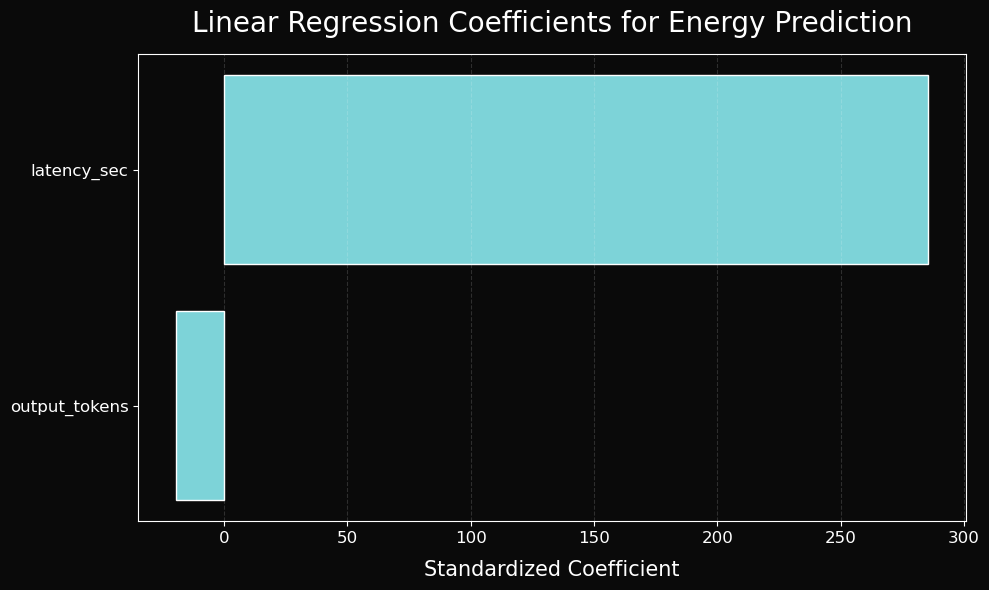

In [6]:
# Bar chart for standardized regression coefficients

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0a0a0a")
ax.set_facecolor("#0a0a0a")

# Plot feature importance on basis of coefficient strength

ax.barh(
    coef_df["Feature"],
    coef_df["Standardized Coefficient"],
    color="#7dd3d8",
    edgecolor="white",
    linewidth=1
)

# Display highest coefficient at top

ax.invert_yaxis()

ax.set_xlabel("Standardized Coefficient", color="white", fontsize=15, labelpad=10)
ax.set_title("Linear Regression Coefficients for Energy Prediction", color="white", fontsize=20, pad=16)

ax.tick_params(colors="white", labelsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.15, color="white")

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()
plt.savefig(
    "energy_regression_coefficients_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()


========== LINEAR REGRESSION RESULTS ==========
R²: 0.9999
MAE: 1.53
RMSE: 2.053

Linear Regression Coefficients:
         Feature  Standardized Coefficient
2    latency_sec                260.093114
0   input_tokens                 13.946780
1  output_tokens                  8.200419


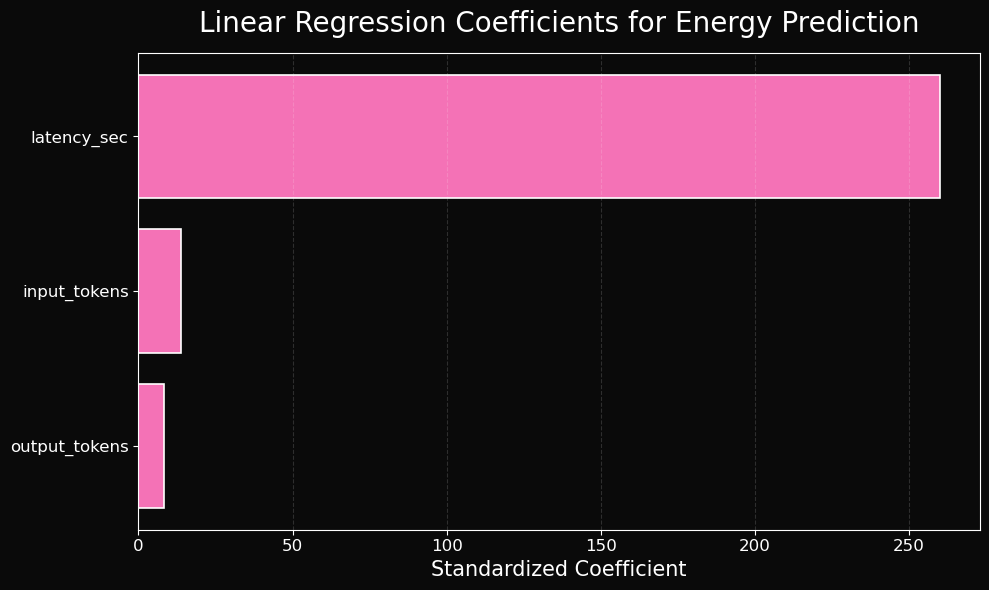

In [7]:
# ENERGY PREDICTION ANALYSIS
# Linear Regression Coefficients

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Load dataset

df = pd.read_csv("clean_runs.csv")
df = df[df["status"] == "success"].copy()

#  Select features

features = [
    "input_tokens",
    "output_tokens",
    "latency_sec"
]

target = "energy_joules"

X = df[features]
y = df[target]

# Linear Regression

linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("regression", LinearRegression())
])

# Train on runtime features

linear_model.fit(X, y)

# Generate predictions

linear_preds = linear_model.predict(X)

# Evaluate model performance

linear_r2 = r2_score(y, linear_preds)
linear_mae = mean_absolute_error(y, linear_preds)
linear_rmse = mean_squared_error(y, linear_preds) ** 0.5

print("\n========== LINEAR REGRESSION RESULTS ==========")
print("R²:", round(linear_r2, 4))
print("MAE:", round(linear_mae, 3))
print("RMSE:", round(linear_rmse, 3))

# Extract standardized regression coefficients

coef_df = pd.DataFrame({
    "Feature": features,
    "Standardized Coefficient": linear_model.named_steps["regression"].coef_
}).sort_values("Standardized Coefficient", ascending=False)

print("\nLinear Regression Coefficients:")
print(coef_df)

# Plot Linear Regression Coefficients

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#0a0a0a")
ax.set_facecolor("#0a0a0a")

ax.barh(
    coef_df["Feature"],
    coef_df["Standardized Coefficient"],
    color="#f472b6",
    edgecolor="white",
    linewidth=1.2
)

ax.invert_yaxis()

ax.set_xlabel("Standardized Coefficient", color="white", fontsize=15)
ax.set_title("Linear Regression Coefficients for Energy Prediction", color="white", fontsize=20, pad=15)

ax.tick_params(colors="white", labelsize=12)
ax.grid(axis="x", linestyle="--", alpha=0.15, color="white")

for spine in ax.spines.values():
    spine.set_color("white")

plt.tight_layout()

plt.savefig(
    "linear_regression_coefficients_dark.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

In [8]:
# Import Libraries

import pandas as pd

# Load model result files
pre = pd.read_csv("pre_run_results.csv")
post = pd.read_csv("post_run_results.csv")

# Display all available metrics
print("=== PRE-RUN RESULTS ===")
print(pre)

print("\n=== POST-RUN RESULTS ===")
print(post)

# Best models only (highest R²)
best_pre = pre.sort_values("r2", ascending=False).iloc[0]
best_post = post.sort_values("r2", ascending=False).iloc[0]

print("\n=== BEST PRE-RUN MODEL ===")
print(best_pre)

print("\n=== BEST POST-RUN MODEL ===")
print(best_post)

# Final summary table
summary = pd.DataFrame([
    {
        "Model Type": "Pre-Inference",
        "R²": best_pre["r2"],
        "MAE": best_pre["mae"],
        "RMSE": best_pre["rmse"]
    },
    {
        "Model Type": "Post-Inference",
        "R²": best_post["r2"],
        "MAE": best_post["mae"],
        "RMSE": best_post["rmse"]
    }
])

print("\n=== FINAL TABLE VALUES ===")
print(summary)

=== PRE-RUN RESULTS ===
              model        r2         mae        rmse
0  LinearRegression  0.126359  197.722298  244.848063
1             Ridge  0.123707  197.984022  245.219367
2      RandomForest -0.014140  181.223749  263.802572
3        ExtraTrees -0.745729  229.926742  346.113425

=== POST-RUN RESULTS ===
              model        r2       mae       rmse
0  LinearRegression  0.999953  1.349205   1.798728
1             Ridge  0.999471  2.599278   6.024889
2      RandomForest  0.998935  4.004251   8.546933
3        ExtraTrees  0.997841  3.529151  12.173188

=== BEST PRE-RUN MODEL ===
model    LinearRegression
r2               0.126359
mae            197.722298
rmse           244.848063
Name: 0, dtype: object

=== BEST POST-RUN MODEL ===
model    LinearRegression
r2               0.999953
mae              1.349205
rmse             1.798728
Name: 0, dtype: object

=== FINAL TABLE VALUES ===
       Model Type        R²         MAE        RMSE
0   Pre-Inference  0.126359  197.7

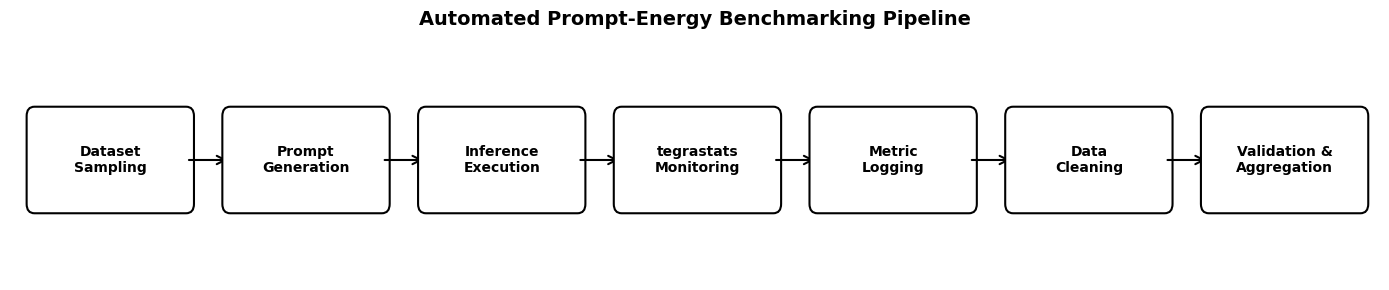

In [9]:
# Visualization for the Pipeline in Report

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

steps = [
    "Dataset\nSampling",
    "Prompt\nGeneration",
    "Inference\nExecution",
    "tegrastats\nMonitoring",
    "Metric\nLogging",
    "Data\nCleaning",
    "Validation &\nAggregation"
]

fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(0, len(steps) * 2)
ax.set_ylim(0, 2)
ax.axis("off")

box_width = 1.55
box_height = 0.75
y = 0.65

for i, step in enumerate(steps):
    x = i * 2 + 0.25

    box = FancyBboxPatch(
        (x, y),
        box_width,
        box_height,
        boxstyle="round,pad=0.08",
        linewidth=1.5,
        facecolor="white",
        edgecolor="black"
    )
    ax.add_patch(box)

    ax.text(
        x + box_width / 2,
        y + box_height / 2,
        step,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

    if i < len(steps) - 1:
        arrow = FancyArrowPatch(
            (x + box_width, y + box_height / 2),
            ((i + 1) * 2 + 0.25, y + box_height / 2),
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.5,
            color="black"
        )
        ax.add_patch(arrow)

plt.title(
    "Automated Prompt-Energy Benchmarking Pipeline",
    fontsize=14,
    fontweight="bold",
    pad=15
)

plt.tight_layout()
plt.savefig("figure1_pipeline.png", dpi=300, bbox_inches="tight")
plt.show()